# 05 — Báo cáo nghiệp vụ và quality gate

Báo cáo chuyển thí nghiệm đã khóa thành các quy tắc hỗ trợ quyết định. Prediction interval và ngưỡng rà soát được calibration từ residual trên validation, không bao giờ từ residual trên holdout.

In [1]:
import json
import os
import warnings
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
MPL_CONFIG = ROOT / ".matplotlib"
MPL_CONFIG.mkdir(exist_ok=True)
os.environ["MPLCONFIGDIR"] = str(MPL_CONFIG)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
# Run minh hoạ mặc định dùng VIC; pipeline nhận ticker khác qua config/CLI.
DATA_PATH = ROOT / "data" / "raw" / "VIC_VN.csv"
REPORT_DIR = ROOT / "evaluation"
REPORT_DIR.mkdir(parents=True, exist_ok=True)
SEED = 42
np.random.seed(SEED)


FEATURES = [
    "return_1d", "return_5d", "volatility_10", "volatility_20",
    "volume_z_20", "rsi_14", "macd_scaled", "price_ma20", "price_ma50",
]
TARGET = "target_return_5d"

def build_frame(raw: pd.DataFrame) -> pd.DataFrame:
    df = raw.copy().sort_values("date").drop_duplicates("date").reset_index(drop=True)
    close = pd.to_numeric(df["close"], errors="coerce")
    volume = pd.to_numeric(df["volume"], errors="coerce")
    returns = np.log(close / close.shift(1))
    delta = close.diff()
    gain = delta.clip(lower=0).ewm(alpha=1 / 14, adjust=False).mean()
    loss = (-delta.clip(upper=0)).ewm(alpha=1 / 14, adjust=False).mean()
    ema12 = close.ewm(span=12, adjust=False).mean()
    ema26 = close.ewm(span=26, adjust=False).mean()
    macd = ema12 - ema26
    df["return_1d"] = returns
    df["return_5d"] = np.log(close / close.shift(5))
    df["volatility_10"] = returns.rolling(10).std()
    df["volatility_20"] = returns.rolling(20).std()
    df["volume_z_20"] = (volume - volume.rolling(20).mean()) / volume.rolling(20).std()
    df["rsi_14"] = (100 - 100 / (1 + gain / loss.replace(0, np.nan))) / 100
    df["macd_scaled"] = macd / close
    df["price_ma20"] = close / close.rolling(20).mean() - 1
    df["price_ma50"] = close / close.rolling(50).mean() - 1
    df[TARGET] = np.log(close.shift(-5) / close)
    return df.replace([np.inf, -np.inf], np.nan)

In [2]:
from sklearn.base import clone
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

raw = pd.read_csv(DATA_PATH, parse_dates=["date"])
frame = build_frame(raw).dropna(subset=FEATURES + [TARGET]).reset_index(drop=True)
n = len(frame); train_end, validation_end = int(n * .60), int(n * .80)
train, validation = frame.iloc[:train_end], frame.iloc[train_end:validation_end]
report = json.loads((REPORT_DIR / "model_metrics.json").read_text(encoding="utf-8"))
selected = report["selected_model"]
estimators = {
    "ridge": Pipeline([("scale", StandardScaler()), ("model", Ridge(alpha=10.0))]),
    "extra_trees": ExtraTreesRegressor(n_estimators=250, min_samples_leaf=8, max_features=.8, random_state=SEED, n_jobs=-1),
    "hist_gradient_boosting": HistGradientBoostingRegressor(max_iter=200, max_leaf_nodes=15, learning_rate=.04, l2_regularization=1.0, random_state=SEED),
}
calibration_model_name = selected if selected in estimators else min(
    (x for x in report["validation"] if x["model"] in estimators), key=lambda x: x["mae"]
)["model"]
calibration_model = clone(estimators[calibration_model_name]).fit(train[FEATURES], train[TARGET])
validation_pred = calibration_model.predict(validation[FEATURES])
absolute_residual = np.abs(validation[TARGET].to_numpy() - validation_pred)
half_width = float(np.quantile(absolute_residual, .80))
half_width

0.046576259109391956

In [3]:
holdout = pd.read_csv(REPORT_DIR / "holdout_predictions.csv", parse_dates=["date"])
holdout["low"] = holdout["prediction"] - half_width
holdout["high"] = holdout["prediction"] + half_width
holdout["covered"] = holdout["actual"].between(holdout["low"], holdout["high"])
holdout["manual_review"] = holdout["low"].le(0) & holdout["high"].ge(0)
coverage = float(holdout["covered"].mean())
false_positive_rate = float(((holdout["prediction"] > 0) & (holdout["actual"] <= 0)).mean())
zero_return_baseline_mae = float(holdout["actual"].abs().mean())
deployment_reasons = []
if report["holdout"]["mae"] > zero_return_baseline_mae:
    deployment_reasons.append("MAE trên holdout không tốt hơn zero-return baseline")
if coverage < .70:
    deployment_reasons.append("interval coverage trên holdout thấp hơn ngưỡng triển khai 70%")
business_metrics = {
    "technical": report["holdout"],
    "zero_return_baseline_mae": zero_return_baseline_mae,
    "interval_coverage_80": coverage,
    "interval_half_width_log_return": half_width,
    "directional_false_positive_rate": false_positive_rate,
    "manual_review_rate": float(holdout["manual_review"].mean()),
}
business_metrics

{'technical': {'mae': 0.073130302131176,
  'rmse': 0.09716242865482892,
  'directional_accuracy': 0.4031890660592255},
 'zero_return_baseline_mae': 0.06067145716831435,
 'interval_coverage_80': 0.43735763097949887,
 'interval_half_width_log_return': 0.046576259109391956,
 'directional_false_positive_rate': 0.12984054669703873,
 'manual_review_rate': 0.8200455580865603}

In [4]:
production_report = {
    "project": "StocKast",
    "ticker": "VIC.VN",
    "scope": "framework dự báo stock time series; report này là run minh hoạ trên VIC",
    "role": "framework Data Scientist và ML Engineer",
    "target": "cumulative log-return 5 phiên sau khi thị trường đóng cửa",
    "selected_model": selected,
    "calibration_model": calibration_model_name,
    "business_baseline": "zero-return",
    "deployment_status": "deployment_blocked" if deployment_reasons else "deployment_ready",
    "deployment_reasons": deployment_reasons,
    "holdout_period": [report["holdout_start"], report["holdout_end"]],
    "metrics": business_metrics,
    "decision_policy": {
        "usage": "chỉ dùng cho kịch bản nghiên cứu và model monitoring",
        "manual_review": "gắn cờ interval cắt qua 0, input ngoài phân phối hoặc cảnh báo schema",
        "business_cap": "clip log-return của model trong +/-0,20; giữ dự báo thô để audit",
        "automation": "không tự động đặt lệnh, phân bổ vốn hay phê duyệt đầu tư",
    },
    "monitoring": ["tính hợp lệ của schema", "feature PSI", "prediction drift", "realized MAE", "interval coverage"],
    "limitations": [
        "run minh hoạ trên một ticker không chứng minh khả năng tổng quát; cần tái lập theo ticker hoặc universe mục tiêu",
        "technical feature từ OHLCV không chứa fundamentals và bối cảnh sự kiện",
        "backtest không chứng minh lợi nhuận tương lai",
    ],
}
(REPORT_DIR / "production_report.json").write_text(json.dumps(production_report, indent=2), encoding="utf-8")
print(json.dumps(production_report, indent=2))

{
  "project": "StocKast",
  "ticker": "VIC.VN",
  "scope": "framework d\u1ef1 b\u00e1o stock time series; report n\u00e0y l\u00e0 run minh ho\u1ea1 tr\u00ean VIC",
  "role": "framework Data Scientist v\u00e0 ML Engineer",
  "target": "cumulative log-return 5 phi\u00ean sau khi th\u1ecb tr\u01b0\u1eddng \u0111\u00f3ng c\u1eeda",
  "selected_model": "gru_rnn",
  "calibration_model": "ridge",
  "business_baseline": "zero-return",
  "deployment_status": "deployment_blocked",
  "deployment_reasons": [
    "MAE tr\u00ean holdout kh\u00f4ng t\u1ed1t h\u01a1n zero-return baseline",
    "interval coverage tr\u00ean holdout th\u1ea5p h\u01a1n ng\u01b0\u1ee1ng tri\u1ec3n khai 70%"
  ],
  "holdout_period": [
    "2024-12-03",
    "2026-08-07"
  ],
  "metrics": {
    "technical": {
      "mae": 0.073130302131176,
      "rmse": 0.09716242865482892,
      "directional_accuracy": 0.4031890660592255
    },
    "zero_return_baseline_mae": 0.06067145716831435,
    "interval_coverage_80": 0.4373576309794

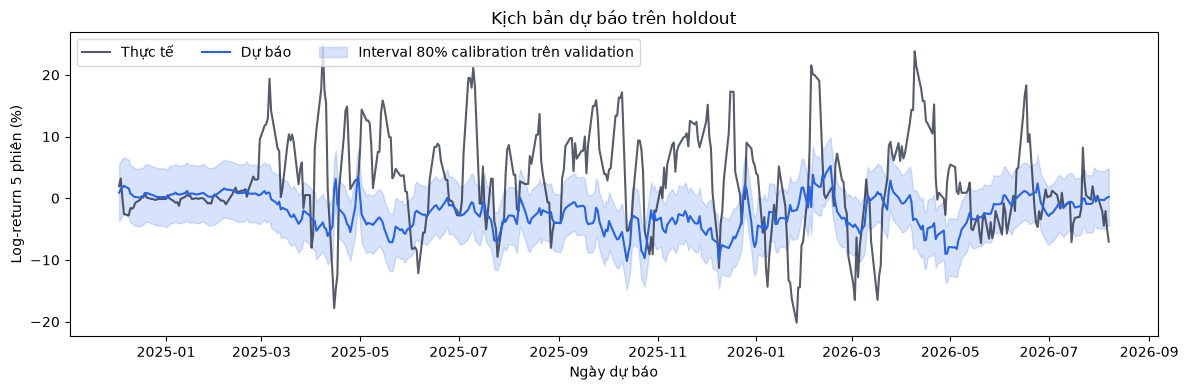

In [5]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(holdout["date"], holdout["actual"] * 100, label="Thực tế", color="#0f172a", alpha=.7)
ax.plot(holdout["date"], holdout["prediction"] * 100, label="Dự báo", color="#2563eb")
ax.fill_between(holdout["date"], holdout["low"] * 100, holdout["high"] * 100, alpha=.18, color="#2563eb", label="Interval 80% calibration trên validation")
ax.set(title="Kịch bản dự báo trên holdout", ylabel="Log-return 5 phiên (%)", xlabel="Ngày dự báo")
ax.legend(ncol=3); plt.tight_layout(); plt.show()